In [2]:
%pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 10.8 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=65b6bccf7f563cb574577c660a53484ad32dcdbd464e415ff38c9b2cc6644337
  Stored in directory: c:\users\catal\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ---------------------

=== RESUMEN ===


,Ticker,Último precio,Retorno diario %,Retorno acumulado %,Volatilidad anual %,Max Drawdown %,RSI 14
0,NVDA,177.39,0.93,99.51,49.5,-36.88,46.9



No se ingresó PRECIO_MANUAL_REFERENCIA.
Si quieres comparar contra Zesty o Perplexity, asigna ese valor en la variable correspondiente.


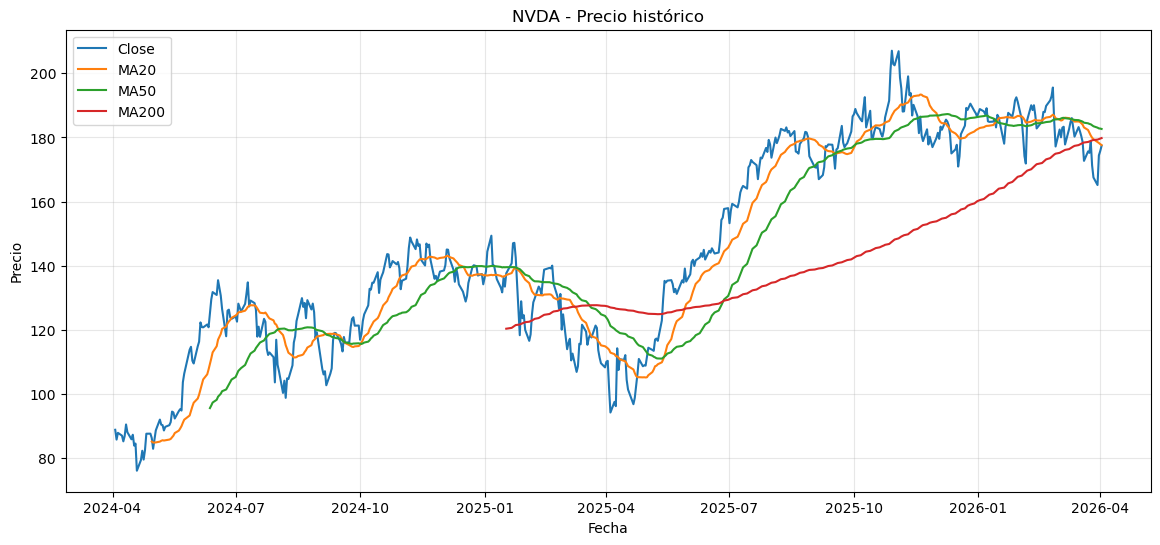

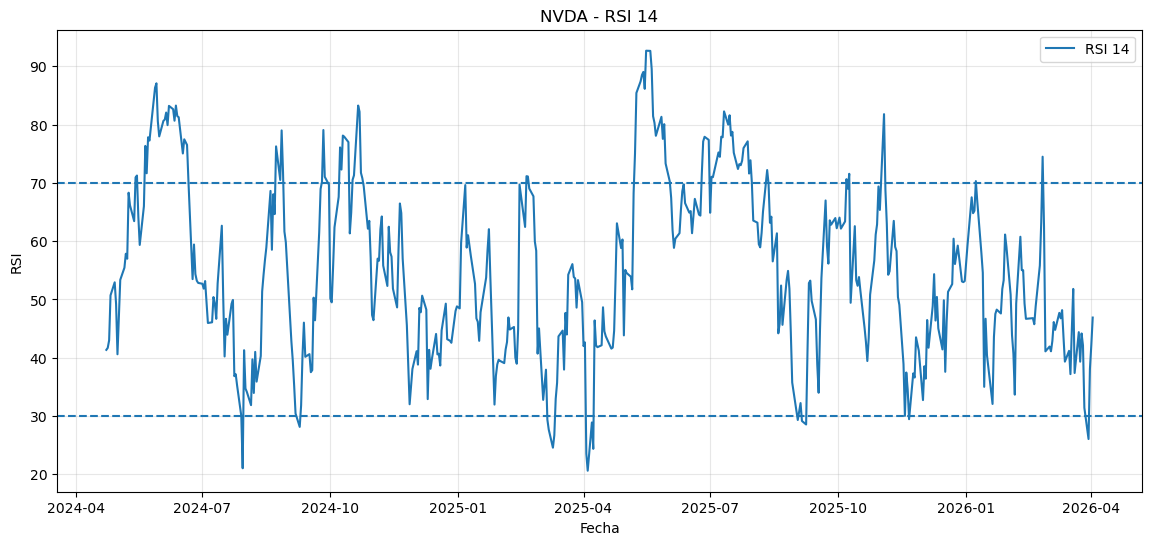

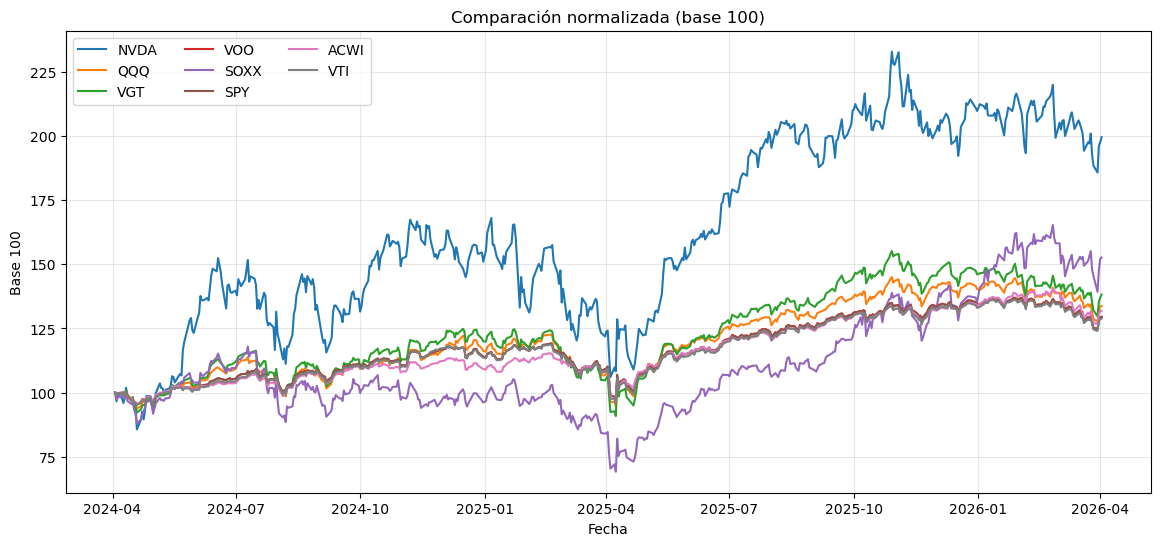


=== ÚLTIMOS PRECIOS DESCARGADOS ===


,Ticker,Último precio
0,ACWI,139.44
1,NVDA,177.39
2,QQQ,584.98
3,SOXX,339.61
4,SPY,655.83
5,VGT,712.65
6,VOO,602.99
7,VTI,323.76


In [1]:
# ============================================================
# PRUEBA JUPYTER LAB - SERIES DE TIEMPO PARA ZESTY / NVIDIA
# Fuente pública: Yahoo Finance vía yfinance
# Objetivo:
# 1) Descargar precios históricos
# 2) Graficar NVDA
# 3) Calcular retornos, volatilidad, medias móviles y RSI
# 4) Comparar el último precio con un valor manual de Zesty/Perplexity
# ============================================================

# Si falta alguna librería, descomenta:
# !pip install yfinance pandas matplotlib numpy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta

plt.rcParams["figure.figsize"] = (14, 6)

# ------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------
TICKERS = [
    "NVDA",   # Nvidia
    "QQQ",    # ETF tecnología Nasdaq
    "VGT",    # Vanguard Information Technology ETF
    "VOO",    # Vanguard S&P 500 ETF
    "SOXX",   # iShares Semiconductor ETF
    "SPY",    # ETF Estados Unidos
    "ACWI",   # ETF acciones mundiales
    "VTI"     # Vanguard Total Market
]

TICKER_PRINCIPAL = "NVDA"
PERIODO = "2y"          # ejemplo: "6mo", "1y", "2y", "5y", "max"
INTERVALO = "1d"        # ejemplo: "1d", "1wk", "1mo"

# Si quieres comparar contra un precio que ves en Zesty / Perplexity:
# escribe manualmente el valor aquí. Si no, deja None.
PRECIO_MANUAL_REFERENCIA = None
FUENTE_REFERENCIA = "Zesty / Perplexity / otra"

# ------------------------------------------------------------
# FUNCIONES
# ------------------------------------------------------------
def descargar_activos(tickers, period="2y", interval="1d"):
    """
    Descarga precios históricos desde Yahoo Finance.
    Devuelve un DataFrame multiíndice o simple según cantidad de tickers.
    """
    data = yf.download(
        tickers=tickers,
        period=period,
        interval=interval,
        auto_adjust=True,
        progress=False,
        group_by="ticker",
        threads=True
    )
    return data


def extraer_close(data, ticker):
    """
    Extrae la serie de cierre ajustado/autoadjusted para 1 ticker.
    """
    if isinstance(data.columns, pd.MultiIndex):
        # Caso varios tickers
        if ticker in data.columns.get_level_values(0):
            serie = data[ticker]["Close"].copy()
        else:
            raise ValueError(f"No se encontró el ticker {ticker} en los datos descargados.")
    else:
        # Caso 1 solo ticker
        serie = data["Close"].copy()

    serie = serie.dropna()
    serie.name = ticker
    return serie


def rsi(series, window=14):
    """
    Calcula RSI clásico.
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    out = 100 - (100 / (1 + rs))
    return out


def volatilidad_anualizada(retornos_diarios):
    """
    Volatilidad anualizada suponiendo 252 ruedas.
    """
    return retornos_diarios.std() * np.sqrt(252)


def max_drawdown(series):
    """
    Máximo drawdown de una serie de precios.
    """
    cummax = series.cummax()
    drawdown = series / cummax - 1
    return drawdown.min()


# ------------------------------------------------------------
# DESCARGA
# ------------------------------------------------------------
data = descargar_activos(TICKERS, period=PERIODO, interval=INTERVALO)

# Serie principal
precio = extraer_close(data, TICKER_PRINCIPAL)

# Indicadores
df = pd.DataFrame(index=precio.index)
df["Close"] = precio
df["Retorno_Diario"] = df["Close"].pct_change()
df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()
df["RSI14"] = rsi(df["Close"], window=14)

# Métricas
ultimo_precio = df["Close"].iloc[-1]
retorno_1d = df["Retorno_Diario"].iloc[-1]
retorno_acum = df["Close"].iloc[-1] / df["Close"].iloc[0] - 1
vol_anual = volatilidad_anualizada(df["Retorno_Diario"].dropna())
mdd = max_drawdown(df["Close"])

resumen = pd.DataFrame({
    "Ticker": [TICKER_PRINCIPAL],
    "Último precio": [ultimo_precio],
    "Retorno diario %": [retorno_1d * 100],
    "Retorno acumulado %": [retorno_acum * 100],
    "Volatilidad anual %": [vol_anual * 100],
    "Max Drawdown %": [mdd * 100],
    "RSI 14": [df["RSI14"].iloc[-1]]
})

print("=== RESUMEN ===")
display(resumen.round(2))

# ------------------------------------------------------------
# COMPARACIÓN MANUAL CONTRA ZESTY / PERPLEXITY
# ------------------------------------------------------------
if PRECIO_MANUAL_REFERENCIA is not None:
    diferencia_abs = ultimo_precio - PRECIO_MANUAL_REFERENCIA
    diferencia_pct = (diferencia_abs / PRECIO_MANUAL_REFERENCIA) * 100

    comparacion = pd.DataFrame({
        "Ticker": [TICKER_PRINCIPAL],
        "Precio Yahoo/yfinance": [ultimo_precio],
        f"Precio manual ({FUENTE_REFERENCIA})": [PRECIO_MANUAL_REFERENCIA],
        "Diferencia absoluta": [diferencia_abs],
        "Diferencia %": [diferencia_pct]
    })

    print("\n=== COMPARACIÓN ===")
    display(comparacion.round(4))
else:
    print("\nNo se ingresó PRECIO_MANUAL_REFERENCIA.")
    print("Si quieres comparar contra Zesty o Perplexity, asigna ese valor en la variable correspondiente.")

# ------------------------------------------------------------
# GRÁFICO 1: PRECIO + MEDIAS MÓVILES
# ------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], label="Close")
ax.plot(df.index, df["MA20"], label="MA20")
ax.plot(df.index, df["MA50"], label="MA50")
ax.plot(df.index, df["MA200"], label="MA200")
ax.set_title(f"{TICKER_PRINCIPAL} - Precio histórico")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# GRÁFICO 2: RSI
# ------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(df.index, df["RSI14"], label="RSI 14")
ax.axhline(70, linestyle="--")
ax.axhline(30, linestyle="--")
ax.set_title(f"{TICKER_PRINCIPAL} - RSI 14")
ax.set_xlabel("Fecha")
ax.set_ylabel("RSI")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# GRÁFICO 3: COMPARACIÓN NORMALIZADA ENTRE ACTIVOS ZESTY
# ------------------------------------------------------------
cierres = {}
for t in TICKERS:
    try:
        cierres[t] = extraer_close(data, t)
    except Exception as e:
        print(f"No se pudo procesar {t}: {e}")

comparativo = pd.DataFrame(cierres).dropna()
comparativo_norm = comparativo / comparativo.iloc[0] * 100

fig, ax = plt.subplots()
for col in comparativo_norm.columns:
    ax.plot(comparativo_norm.index, comparativo_norm[col], label=col)

ax.set_title("Comparación normalizada (base 100)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Base 100")
ax.legend(ncol=3)
ax.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# TABLA FINAL DE PRECIOS ACTUALES
# ------------------------------------------------------------
ultimos = comparativo.tail(1).T.reset_index()
ultimos.columns = ["Ticker", "Último precio"]

print("\n=== ÚLTIMOS PRECIOS DESCARGADOS ===")
display(ultimos.sort_values("Ticker").reset_index(drop=True).round(4))

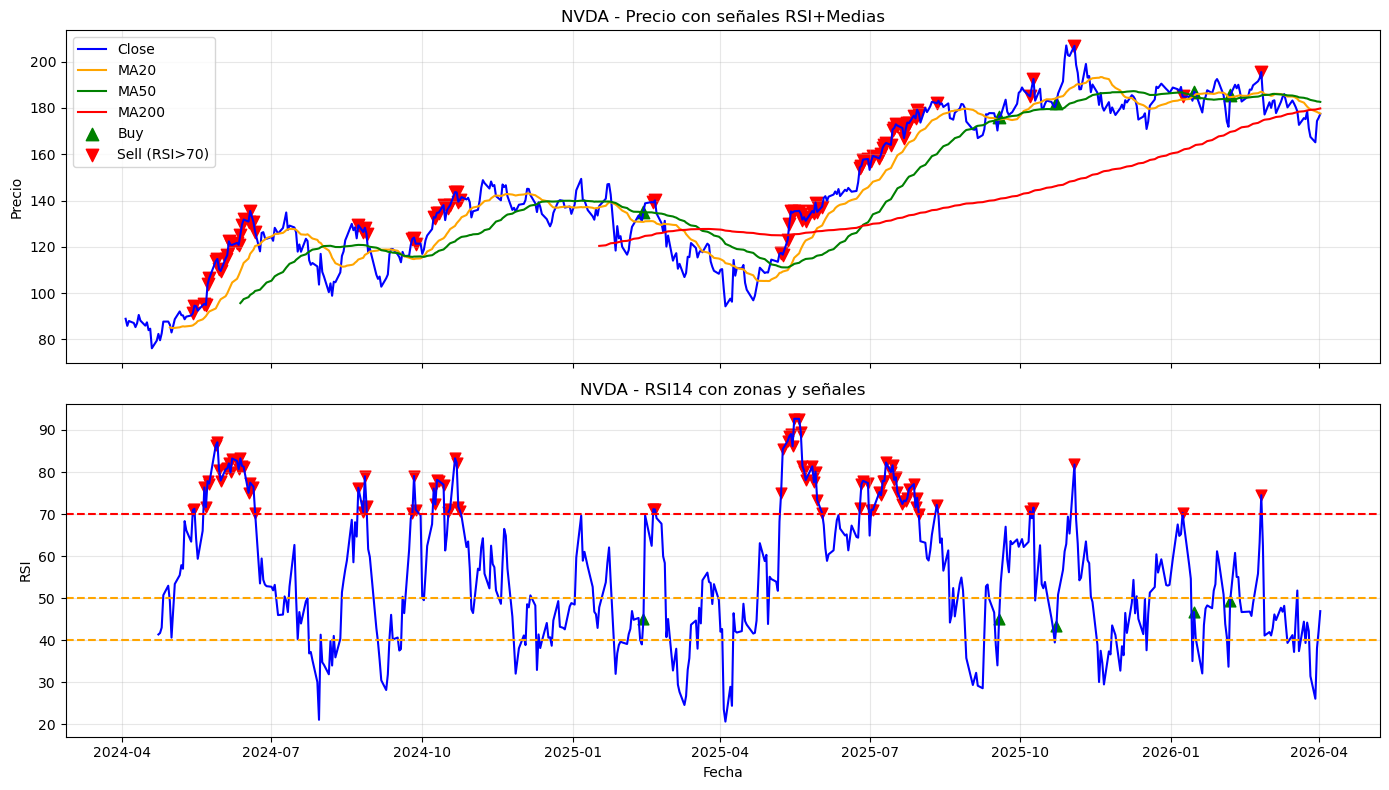

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Condición de tendencia alcista
cond_tendencia = (df["Close"] > df["MA50"]) & (df["MA50"] > df["MA200"])

# 2) Señales de compra: tendencia alcista + RSI entra a 40‑50 viniendo de <40
compra = (
    cond_tendencia
    & df["RSI14"].between(40, 50)
    & (df["RSI14"].shift(1) < 40)
)

# 3) Señales de venta: RSI > 70
venta = df["RSI14"] > 70

# 4) Guardar tabla de señales
senales = df[["Close", "RSI14"]].copy()
senales["Buy"] = compra
senales["Sell"] = venta
senales.to_csv("nvda_senales_rsi_ma.csv")

# 5) Gráfico precio + señales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df.index, df["Close"], label="Close", color="blue")
ax1.plot(df.index, df["MA20"], label="MA20", color="orange")
ax1.plot(df.index, df["MA50"], label="MA50", color="green")
ax1.plot(df.index, df["MA200"], label="MA200", color="red")

ax1.scatter(df.index[compra], df["Close"][compra],
            marker="^", color="green", s=80, label="Buy")
ax1.scatter(df.index[venta], df["Close"][venta],
            marker="v", color="red", s=80, label="Sell (RSI>70)")

ax1.set_title("NVDA - Precio con señales RSI+Medias")
ax1.set_ylabel("Precio")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 6) Gráfico RSI + señales
ax2.plot(df.index, df["RSI14"], label="RSI14", color="blue")
ax2.axhline(70, linestyle="--", color="red")
ax2.axhline(40, linestyle="--", color="orange")
ax2.axhline(50, linestyle="--", color="orange")

ax2.scatter(df.index[compra], df["RSI14"][compra],
            marker="^", color="green", s=60)
ax2.scatter(df.index[venta], df["RSI14"][venta],
            marker="v", color="red", s=60)

ax2.set_title("NVDA - RSI14 con zonas y señales")
ax2.set_xlabel("Fecha")
ax2.set_ylabel("RSI")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Último precio NVDA: 177.39
Retorno diario medio: 0.0019
Volatilidad diaria: 0.0312

=== Distribución de precios simulados al final del horizonte ===
Escenario pesimista (5%):  119.67
Escenario mediano  (50%): 215.30
Escenario optimista (95%): 359.61


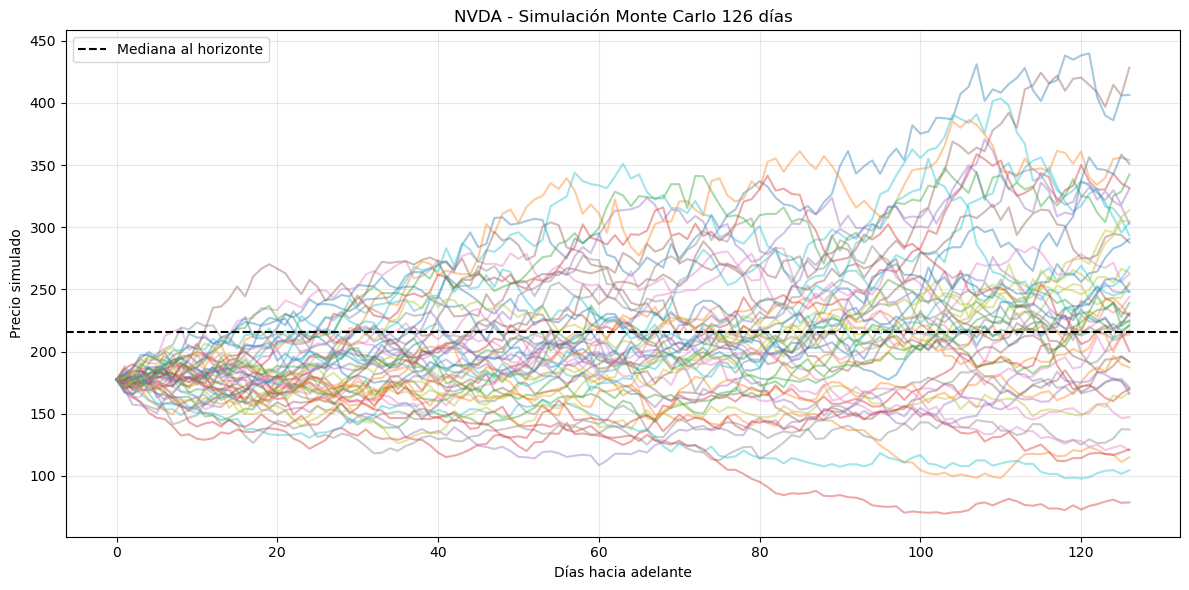

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ========= PARÁMETROS =========
HORIZONTE_DIAS = 126    # ~6 meses bursátiles
N_SIMULACIONES = 500    # número de trayectorias futuras

# ========= USAR PRECIOS YA CALCULADOS EN df =========
# df debe tener al menos la columna "Close"
precio = df["Close"].dropna()

# ========= CÁLCULO DE RETORNOS HISTÓRICOS =========
ret_diario = precio.pct_change().dropna()
mu_diario = ret_diario.mean()          # retorno promedio diario
sigma_diario = ret_diario.std()        # volatilidad diaria
ultimo_precio = float(precio.iloc[-1]) # asegurar escalar

print(f"Último precio NVDA: {ultimo_precio:.2f}")
print(f"Retorno diario medio: {mu_diario:.4f}")
print(f"Volatilidad diaria: {sigma_diario:.4f}")

# ========= SIMULACIÓN MONTE CARLO (Geometric Brownian Motion) =========
np.random.seed(42)
dt = 1.0  # 1 día

trayectorias = np.zeros((HORIZONTE_DIAS + 1, N_SIMULACIONES))
trayectorias[0] = ultimo_precio

for t in range(1, HORIZONTE_DIAS + 1):
    rand = np.random.normal(0, 1, N_SIMULACIONES)
    # S_{t+1} = S_t * exp( (mu - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z )
    trayectorias[t] = trayectorias[t-1] * np.exp(
        (mu_diario - 0.5 * sigma_diario**2) * dt
        + sigma_diario * np.sqrt(dt) * rand
    )

# ========= ESTADÍSTICAS AL FINAL DEL HORIZONTE =========
precios_futuros = trayectorias[-1]
p5, p50, p95 = np.percentile(precios_futuros, [5, 50, 95])

print("\n=== Distribución de precios simulados al final del horizonte ===")
print(f"Escenario pesimista (5%):  {p5:.2f}")
print(f"Escenario mediano  (50%): {p50:.2f}")
print(f"Escenario optimista (95%): {p95:.2f}")

# ========= GRÁFICO DE TRAYECTORIAS =========
dias = np.arange(HORIZONTE_DIAS + 1)

plt.figure(figsize=(12, 6))
plt.plot(dias, trayectorias[:, :50], alpha=0.4)  # mostrar solo 50 trayectorias
plt.axhline(p50, color="black", linestyle="--", label="Mediana al horizonte")
plt.title(f"NVDA - Simulación Monte Carlo {HORIZONTE_DIAS} días")
plt.xlabel("Días hacia adelante")
plt.ylabel("Precio simulado")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
import subprocess
subprocess.run(['pip', 'install', 'arch', 'yfinance', 'statsmodels', '-q'])

CompletedProcess(args=['pip', 'install', 'arch', 'yfinance', 'statsmodels', '-q'], returncode=0)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from scipy.stats import t as t_dist
from arch import arch_model
import yfinance as yf

print('✅ Librerías cargadas')

✅ Librerías cargadas


In [6]:
TICKER  = 'NVDA'
PERIODO = '2y'

raw    = yf.download(TICKER, period=PERIODO, interval='1d',
                     auto_adjust=True, progress=False)
precio = raw['Close'].dropna().squeeze()
ret    = np.log(precio / precio.shift(1)).dropna() * 100  # en %

print(f'Período:       {precio.index[0].date()} → {precio.index[-1].date()}')
print(f'Observaciones: {len(ret)}')
print(f'Último precio: {float(precio.iloc[-1]):.2f} USD')

Período:       2024-04-03 → 2026-04-02
Observaciones: 501
Último precio: 177.39 USD


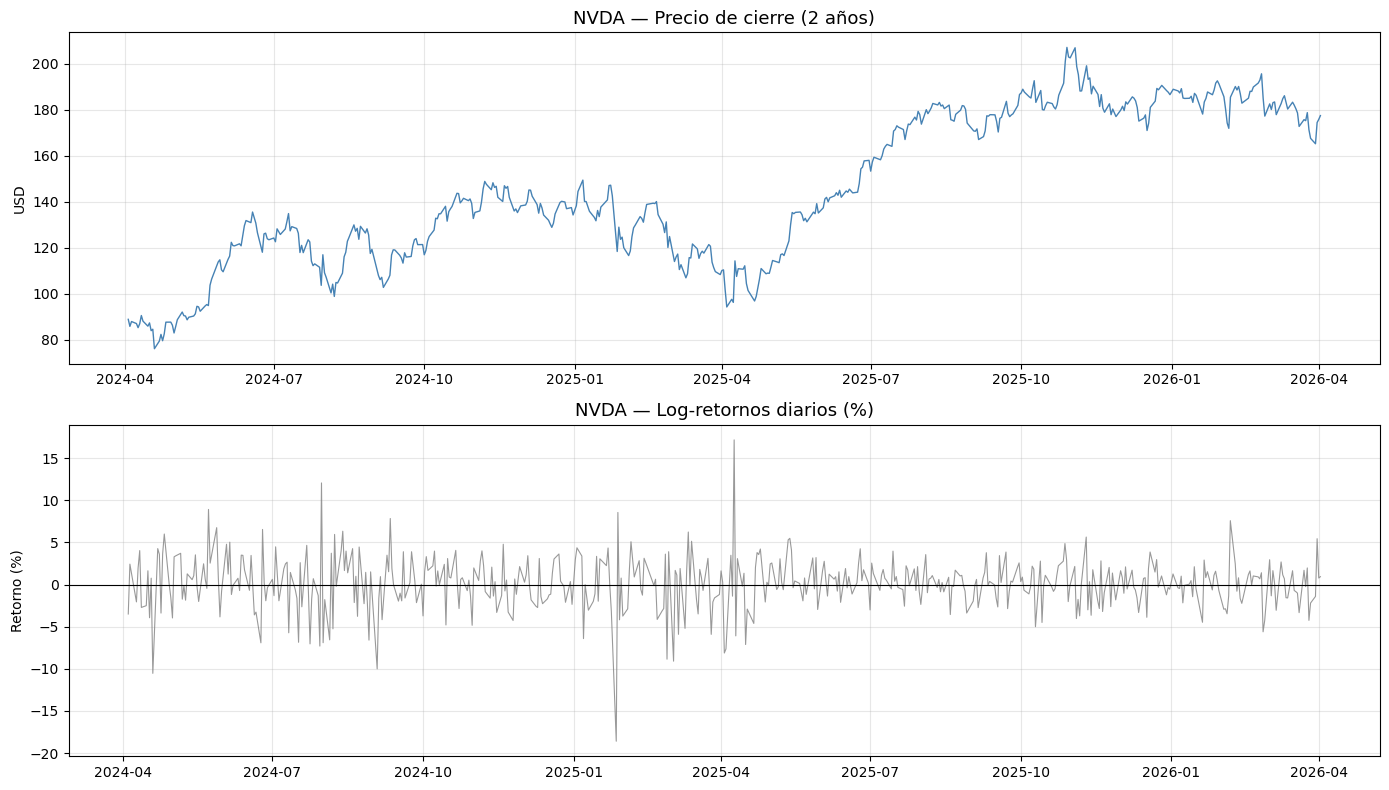


=== Estadísticas log-retornos ===
count    501.0000
mean       0.1379
std        3.1225
min      -18.5946
25%       -1.5657
50%        0.2664
75%        1.8978
max       17.1621
Name: NVDA, dtype: float64
Skewness: -0.3042  |  Kurtosis: 4.6423


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(precio.index, precio.values, color='steelblue', linewidth=1)
axes[0].set_title(f'{TICKER} — Precio de cierre (2 años)', fontsize=13)
axes[0].set_ylabel('USD'); axes[0].grid(alpha=0.3)

axes[1].plot(ret.index, ret.values, color='gray', linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title(f'{TICKER} — Log-retornos diarios (%)', fontsize=13)
axes[1].set_ylabel('Retorno (%)'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('\n=== Estadísticas log-retornos ===')
print(ret.describe().round(4))
print(f'Skewness: {ret.skew():.4f}  |  Kurtosis: {ret.kurtosis():.4f}')

In [8]:
# Los PRECIOS son camino aleatorio (no estacionarios)
# Los RETORNOS deben ser estacionarios → apto para GARCH

adf = adfuller(ret, maxlag=12)
print('=== Test Dickey-Fuller Aumentado ===')
print(f'Estadístico: {adf[0]:.4f}')
print(f'p-valor:     {adf[1]:.6f}')

if adf[1] < 0.05:
    print('✅ p < 5% → ESTACIONARIO. Retornos aptos para GARCH.')
else:
    print('⚠️  p ≥ 5% → Revisar la serie.')

=== Test Dickey-Fuller Aumentado ===
Estadístico: -12.4857
p-valor:     0.000000
✅ p < 5% → ESTACIONARIO. Retornos aptos para GARCH.


In [9]:
# Clase: retornos simples NO deben tener autocorrelación (no free lunch)
# Retornos² SÍ pueden tenerla → justifica GARCH

lb1 = acorr_ljungbox(ret,    lags=[5, 12], return_df=True)
lb2 = acorr_ljungbox(ret**2, lags=[5, 12], return_df=True)

print('Ljung-Box retornos simples (esperamos p > 0.05):')
print(lb1.round(4))
print('\nLjung-Box retornos² (volatilidad, esperamos p < 0.05 → GARCH válido):')
print(lb2.round(4))

Ljung-Box retornos simples (esperamos p > 0.05):
    lb_stat  lb_pvalue
5   21.4954     0.0007
12  24.2236     0.0190

Ljung-Box retornos² (volatilidad, esperamos p < 0.05 → GARCH válido):
    lb_stat  lb_pvalue
5   20.4225     0.0010
12  23.3496     0.0249


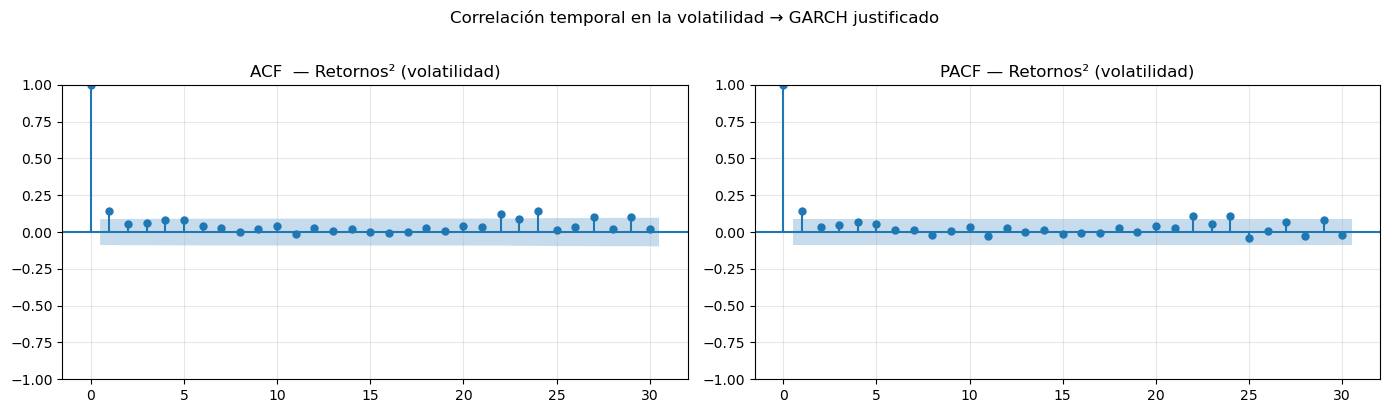

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( ret**2, lags=30, ax=axes[0], title='ACF  — Retornos² (volatilidad)')
plot_pacf(ret**2, lags=30, ax=axes[1], title='PACF — Retornos² (volatilidad)',
          method='ywm')
for ax in axes: ax.grid(alpha=0.3)
plt.suptitle('Correlación temporal en la volatilidad → GARCH justificado', y=1.02)
plt.tight_layout(); plt.show()

In [11]:
# σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}
# Premio Nobel Robert Engle (2003) — estándar de la industria

modelo    = arch_model(ret, vol='Garch', p=1, q=1, dist='t', mean='Constant')
resultado = modelo.fit(disp='off')
print(resultado.summary())

alpha = resultado.params['alpha[1]']
beta  = resultado.params['beta[1]']
print(f'\n⚡ Persistencia (α+β): {alpha+beta:.4f}')
print('  Cercano a 1 = shocks de volatilidad muy persistentes (típico en tech).')

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         NVDA   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1231.87
Distribution:      Standardized Student's t   AIC:                           2473.74
Method:                  Maximum Likelihood   BIC:                           2494.82
                                              No. Observations:                  501
Date:                     vie, abr. 03 2026   Df Residuals:                      500
Time:                              20:07:55   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

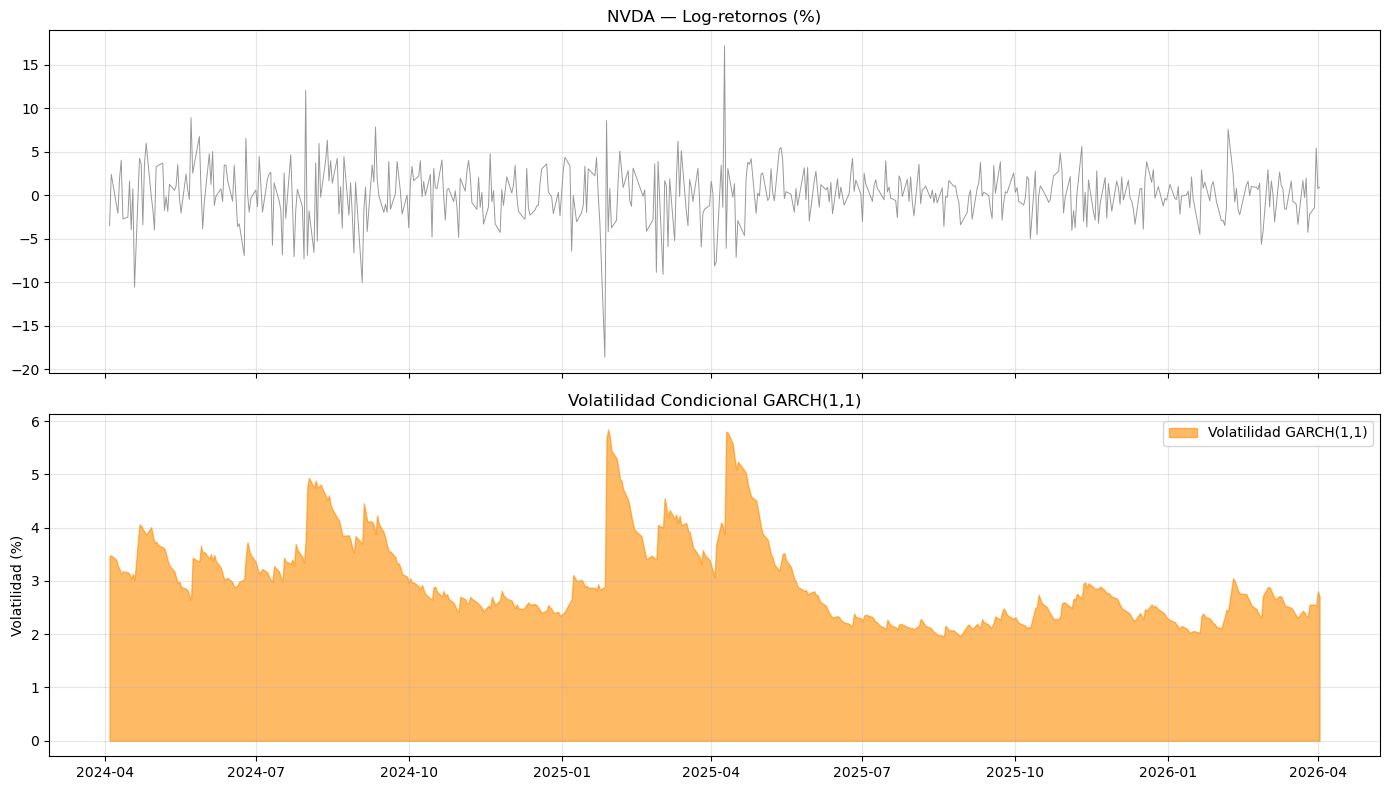

Observa: volatilidad SUBE en crisis y BAJA en períodos tranquilos.


In [12]:
vol_c = resultado.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(ret.index, ret.values, color='gray', linewidth=0.7, alpha=0.8)
axes[0].set_title(f'{TICKER} — Log-retornos (%)', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].fill_between(vol_c.index, vol_c.values, alpha=0.6, color='darkorange',
                     label='Volatilidad GARCH(1,1)')
axes[1].set_title('Volatilidad Condicional GARCH(1,1)', fontsize=12)
axes[1].set_ylabel('Volatilidad (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print('Observa: volatilidad SUBE en crisis y BAJA en períodos tranquilos.')

In [22]:
HORIZONTE    = 5      # días hábiles hacia adelante
NIVEL_RIESGO = 0.01   # 1% (estándar finanza / Basilea)

forecast = resultado.forecast(horizon=HORIZONTE, reindex=False)
vol_pred = np.sqrt(forecast.variance.values[-1])
nu       = resultado.params['nu']
quantil  = t_dist.ppf(NIVEL_RIESGO, df=nu)
UP       = float(precio.iloc[-1])

print('=' * 56)
print(f'  VALOR EN RIESGO (VaR 99%) — {TICKER}')
print('=' * 56)
print(f'  Último precio: {UP:.2f} USD  |  Nivel riesgo: {NIVEL_RIESGO*100:.0f}%\n')
print(f'  {"Día":>5}  {"Vol pred (%)":>13}  {"VaR (%)":>9}  {"VaR (USD)":>10}')
print(f'  {"-"*5}  {"-"*13}  {"-"*9}  {"-"*10}')

for h in range(HORIZONTE):
    v  = float(vol_pred[h])
    vp = abs(quantil * v)
    vu = UP * vp / 100
    print(f'  {h+1:>5}  {v:>13.4f}  {vp:>8.2f}%  {vu:>9.2f} USD')

var1d = UP * abs(quantil * float(vol_pred[0])) / 100
print(f'\n📌 Con 99% de confianza, la pérdida mañana NO superará {var1d:.2f} USD/acción.')

  VALOR EN RIESGO (VaR 99%) — NVDA
  Último precio: 177.39 USD  |  Nivel riesgo: 1%

    Día   Vol pred (%)    VaR (%)   VaR (USD)
  -----  -------------  ---------  ----------
      1         2.6355      8.33%      14.77 USD
      2         2.6467      8.36%      14.84 USD
      3         2.6575      8.40%      14.90 USD
      4         2.6680      8.43%      14.96 USD
      5         2.6782      8.46%      15.01 USD

📌 Con 99% de confianza, la pérdida mañana NO superará 14.77 USD/acción.


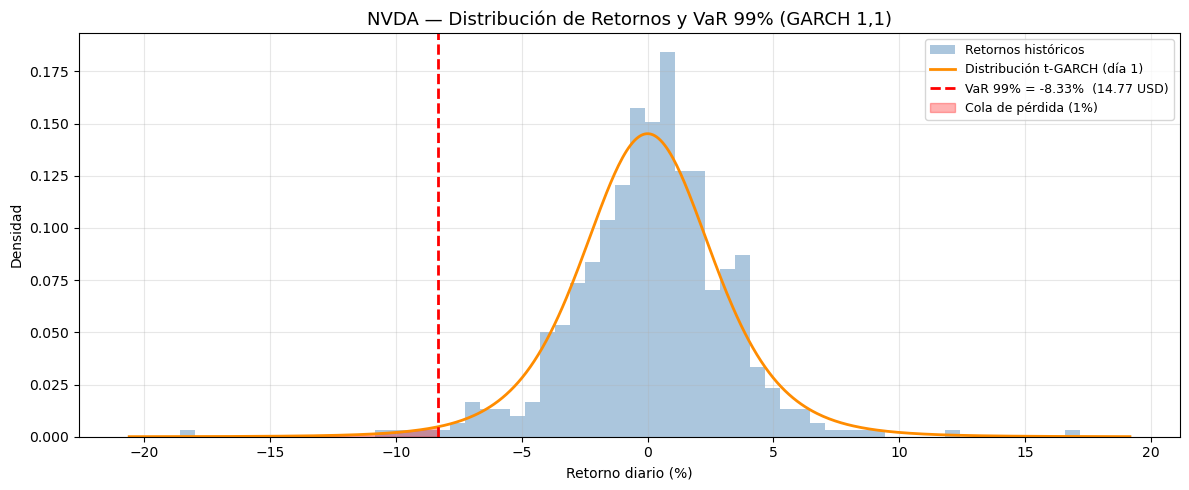

In [23]:
nu_val  = resultado.params['nu']
vol_hoy = float(vol_pred[0])
var_1d  = abs(t_dist.ppf(NIVEL_RIESGO, df=nu_val)) * vol_hoy

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(ret, bins=60, density=True, alpha=0.45, color='steelblue',
        label='Retornos históricos')

x = np.linspace(ret.min()-2, ret.max()+2, 500)
ax.plot(x, t_dist.pdf(x/vol_hoy, df=nu_val)/vol_hoy,
        'darkorange', linewidth=2, label='Distribución t-GARCH (día 1)')

ax.axvline(-var_1d, color='red', linestyle='--', linewidth=2,
           label=f'VaR 99% = -{var_1d:.2f}%  ({float(precio.iloc[-1])*var_1d/100:.2f} USD)')

x_r = np.linspace(ret.min()-2, -var_1d, 200)
ax.fill_between(x_r, t_dist.pdf(x_r/vol_hoy, df=nu_val)/vol_hoy,
                alpha=0.3, color='red', label='Cola de pérdida (1%)')

ax.set_title(f'{TICKER} — Distribución de Retornos y VaR 99% (GARCH 1,1)', fontsize=13)
ax.set_xlabel('Retorno diario (%)'); ax.set_ylabel('Densidad')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()